
# Simulación del Control Enzimático: Cinética de Michaelis‑Menten mediante el Método de Euler

**Curso:** Métodos Numéricos / Modelado y Simulación
**Práctica:** Identificación — Simulación del control enzimático
**Autora:** Mariana
**Fecha:** 30 de agosto de 2026

---

### Declaración de uso de Inteligencia Artificial

Este informe fue elaborado con asistencia de **Claude (Anthropic, modelo Claude Sonnet 4.6)** para:
- Estructurar la redacción del marco teórico y la discusión (sección 1 y sección 7), a partir del material del enunciado y de fuentes bibliográficas primarias citadas explícitamente.
- Generar y depurar el código Python (secciones 3–6).
- Redactar el andamiaje de las conclusiones metodológicas (sección 7), que fueron luego revisadas y ajustadas por la autora.

De acuerdo con las indicaciones de la práctica, **las conclusiones generadas con asistencia de IA no deben tomarse como evaluables por sí mismas**; se presentan como punto de partida y deben ser leídas de forma crítica, contrastando cada afirmación con las gráficas y los datos numéricos obtenidos en este mismo notebook.

---

## Índice

1. [Marco teórico](#1)
2. [Objetivos](#2)
3. [Metodología numérica: formulación del modelo y discretización de Euler](#3)
4. [Implementación en Python](#4)
5. [Simulación 1 — Caso control](#5)
6. [Simulación 2 — Variación de concentraciones iniciales de sustrato y enzima](#6)
7. [Simulación 3 — Variación de las constantes cinéticas](#7)
8. [Análisis comparativo y discusión](#8)
9. [Conclusiones generales](#9)
10. [Referencias](#10)



## 1. Marco teórico <a id="1"></a>

### 1.1 Cinética enzimática y el problema de la saturación

Las enzimas son catalizadores biológicos que aumentan la velocidad de una reacción química sin
alterar el equilibrio termodinámico entre sustrato y producto (Nelson & Cox, 2017). A diferencia de
una reacción no catalizada, la velocidad de una reacción enzimática **no crece linealmente** con la
concentración de sustrato [S]: a bajas [S] la velocidad aumenta casi proporcionalmente, pero al
incrementar [S] la enzima se satura y la velocidad tiende asintóticamente a un valor máximo,
$V_{max}$, que no se sobrepasa sin importar cuánto sustrato adicional se agregue (Cornish-Bowden,
2012). Este comportamiento saturable es la firma cinética de que la catálisis ocurre a través de un
**complejo enzima-sustrato** intermedio, y no por colisión directa productiva entre E y S.

### 1.2 El mecanismo de Michaelis-Menten

El modelo cinético que formaliza esta observación fue propuesto originalmente por Michaelis y Menten
(1913) y reanalizado con métodos computacionales modernos por Johnson y Goody (2011), quienes
tradujeron el artículo original del alemán y mostraron que el análisis de datos de 1913 era
sorprendentemente riguroso para su época. El mecanismo de reacción de un único sustrato se
describe como:

$$
E + S \underset{k_{-1}}{\overset{k_1}{\rightleftharpoons}} ES \overset{k_2}{\longrightarrow} E + P
$$

donde:
- $k_1$ es la constante de velocidad de asociación de E y S para formar el complejo *ES*,
- $k_{-1}$ (también denotada $k_3$ en algunos textos, incluida la guía de esta práctica) es la constante
  de velocidad de disociación de *ES* de vuelta a E + S,
- $k_2$ (también llamada $k_{cat}$) es la constante de velocidad de la etapa catalítica limitante,
  en la que *ES* se transforma irreversiblemente en E + P.

Asumiendo cinética elemental de primer y segundo orden para cada etapa, el sistema de ecuaciones
diferenciales ordinarias (ODEs) que describe la evolución temporal de las cuatro especies es:

$$
\begin{aligned}
\frac{d[S]}{dt} &= -k_1[E][S] + k_{-1}[ES] \\
\frac{d[E]}{dt} &= -k_1[E][S] + k_{-1}[ES] + k_2[ES] \\
\frac{d[ES]}{dt} &= k_1[E][S] - k_{-1}[ES] - k_2[ES] \\
\frac{d[P]}{dt} &= k_2[ES]
\end{aligned}
$$

Este sistema conserva la masa total de enzima, $[E] + [ES] = [E]_{tot}$, en todo instante — una
propiedad que puede usarse como verificación numérica de la simulación (Chapra & Canale, 2007).

### 1.3 La aproximación de estado cuasi-estacionario y la ecuación de Michaelis-Menten

Bajo la aproximación de equilibrio (o, más generalmente, de estado cuasi-estacionario de Briggs y
Haldane, en la que se asume $d[ES]/dt \approx 0$ una vez transcurrido el transitorio inicial), el
sistema de ODEs se puede reducir a la conocida ecuación algebraica de Michaelis-Menten:

$$
v = \frac{V_{max}[S]}{K_m + [S]}
$$

donde $V_{max} = k_2[E]_{tot}$ es la velocidad máxima alcanzable cuando toda la enzima está en forma
de complejo *ES*, y $K_m \approx \dfrac{k_{-1} + k_2}{k_1}$ es la **constante de Michaelis**: la
concentración de sustrato a la cual la velocidad de reacción es exactamente la mitad de $V_{max}$.
$K_m$ tiene unidades de concentración y funciona como una medida inversa de la afinidad aparente de
la enzima por el sustrato (a menor $K_m$, mayor afinidad aparente) (Cornish-Bowden, 2012; Johnson &
Goody, 2011).

Es importante notar — y esto es una distinción metodológica central en este informe — que la
ecuación algebraica de Michaelis-Menten es una **solución aproximada de estado estacionario**, válida
solo después de que el sistema transitorio ha relajado y mientras $[S]$ no se agote apreciablemente.
La simulación completa del sistema de ODEs (secciones 5–7) permite observar tanto el transitorio de
formación del complejo *ES* como la fase cuasi-estacionaria, y por tanto ofrece información que la
ecuación algebraica, por construcción, no puede mostrar.

### 1.4 Método de Euler para la integración numérica

El sistema de ODEs anterior no tiene, en general, solución analítica cerrada para las cuatro
variables en función del tiempo, por lo que se recurre a integración numérica. El **método de Euler
explícito (o método de Euler hacia adelante)** es el esquema de un paso más simple para aproximar la
solución de un problema de valor inicial

$$
\frac{dy}{dt} = f(t, y), \qquad y(t_0) = y_0,
$$

y consiste en aproximar la derivada por la pendiente de la recta tangente en el instante actual,
extrapolando linealmente un paso de tiempo $h$ hacia adelante (Burden & Faires, 2011; Chapra &
Canale, 2007):

$$
y_{i+1} = y_i + h \cdot f(t_i, y_i), \qquad i = 0, 1, 2, \ldots
$$

El método de Euler es de **primer orden**: su error de truncamiento local es $O(h^2)$ y el error
global acumulado es $O(h)$ (Burden & Faires, 2011). Esto significa que, para garantizar una buena
aproximación, el paso $h$ debe ser suficientemente pequeño en relación con la escala de tiempo más
rápida del sistema (en este caso, la escala de formación/disociación del complejo *ES*, gobernada por
$k_1, k_{-1}, k_2$). Un paso demasiado grande puede producir soluciones que oscilan, se vuelven
negativas de forma no física, o divergen — un riesgo particularmente relevante en sistemas de ODEs
acopladas y potencialmente *stiff* como el que aquí se resuelve. Este riesgo se documenta
explícitamente en la sección 8 al examinar la sensibilidad del método al paso de integración.

### 1.5 Preguntas que guían este informe

Siguiendo el procedimiento de la práctica, este informe no se limita a reportar gráficas: para cada
simulación se busca (i) verificar que el resultado numérico es consistente con la conservación de
masa de enzima, (ii) contrastar la solución transitoria completa contra la aproximación algebraica de
estado estacionario, y (iii) **distinguir explícitamente lo que las curvas muestran (un hecho
numérico) de lo que se interpreta bioquímicamente a partir de ellas** (una inferencia que depende de
supuestos del modelo). Esta distinción se retoma en la sección 8, en respuesta directa al tipo de
observación metodológica que exige separar evidencia numérica de interpretación biológica.



## 2. Objetivos <a id="2"></a>

**Objetivo general.** Desarrollar e implementar en Python, mediante el método de Euler explícito, una
simulación del control enzimático descrito por el mecanismo de Michaelis-Menten, y analizar cómo
distintas condiciones iniciales y constantes cinéticas afectan la dinámica de sustrato, enzima,
complejo y producto.

**Objetivos específicos:**

1. Implementar el sistema de cuatro ODEs acopladas (ecs. 1.2) mediante el método de Euler, organizando
   el código en funciones reutilizables.
2. Simular el caso control con $k_1=2\ \text{mol}^{-1}\text{s}^{-1}$, $k_2=1.5\ \text{s}^{-1}$,
   $k_3=1\ \text{s}^{-1}$, $[S]_0=10$ mol, $[E]_0=6$ mol, verificando la conservación de masa de
   enzima como control de calidad numérico.
3. Calcular $K_m$ y $V_{max}$ analíticamente a partir de las constantes cinéticas y graficar la curva
   de velocidad de reacción vs. concentración de sustrato, señalando el punto $(K_m,\ V_{max}/2)$.
4. Repetir la simulación variando las concentraciones iniciales de sustrato y enzima, y nuevamente
   variando las constantes cinéticas, y comparar los resultados frente al caso control.
5. Discutir, con base estrictamente en lo observado en las simulaciones, qué se puede y qué no se
   puede concluir sobre el comportamiento del sistema enzimático.



## 3. Metodología numérica: formulación del modelo y discretización de Euler <a id="3"></a>

Aplicando la discretización de Euler (sección 1.4) a cada una de las cuatro ODEs del sistema
(sección 1.2), con paso de integración $h=dt$, se obtiene el esquema iterativo explícito que se
implementa en la sección 4:

$$
\begin{aligned}
S_{i+1} &= S_i + h\left(-k_1 E_i S_i + k_3 C_i\right) \\
E_{i+1} &= E_i + h\left(-k_1 E_i S_i + k_3 C_i + k_2 C_i\right) \\
C_{i+1} &= C_i + h\left(k_1 E_i S_i - k_3 C_i - k_2 C_i\right) \\
P_{i+1} &= P_i + h\left(k_2 C_i\right)
\end{aligned}
$$

donde se usa la notación de la guía de la práctica: $k_3 \equiv k_{-1}$ (constante de disociación de
*ES*) y $C \equiv [ES]$. Los valores iniciales son $S_0=10$, $E_0=6$, $C_0=0$, $P_0=0$ moles para el
caso control, y el vector de tiempo se genera desde $t=0$ hasta el tiempo de simulación, con paso
$dt = 0.01$ s.

Para la curva de velocidad de reacción en estado estacionario se usa la ecuación algebraica de
Michaelis-Menten (sección 1.3), evaluada sobre un vector de concentraciones de sustrato de 0 hasta la
concentración máxima especificada (50 moles), con $K_m=(k_3+k_2)/k_1$ y $V_{max}=k_2 [E]_0$.



## 4. Implementación en Python <a id="4"></a>

Se organiza el código en funciones (`def`), tal como recomienda la guía de la práctica. Cada función
tiene una única responsabilidad: (i) integrar el sistema de ODEs mediante Euler, (ii) calcular la
velocidad de reacción en estado estacionario en función de [S], y (iii) graficar los resultados. Esto
facilita reutilizar exactamente el mismo código en las tres simulaciones, cambiando únicamente los
parámetros de entrada — una práctica que reduce el riesgo de errores de copiar/pegar y hace explícito
qué cambia entre un ensayo y otro.


In [1]:
# =====================================================================
# Librerías necesarias
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt

# Configuración estética global de las gráficas (no afecta los resultados numéricos)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11


In [2]:
def simular_michaelis_menten(S0, E0, k1, k2, k3, dt, t_sim):
    '''
    Integra el sistema de ODEs de Michaelis-Menten mediante el método de Euler explícito.

    Parámetros
    ----------
    S0, E0 : float
        Concentraciones iniciales de sustrato y enzima libre (mol). C0 = 0, P0 = 0 por definición
        del caso control (no se han formado complejo ni producto en t = 0).
    k1 : float
        Constante de velocidad de asociación E + S -> ES (1/(mol*s)).
    k2 : float
        Constante de velocidad catalítica ES -> E + P (1/s).
    k3 : float
        Constante de velocidad de disociación ES -> E + S (1/s). Equivale a k_{-1}.
    dt : float
        Paso de integración de Euler (s).
    t_sim : float
        Tiempo total de simulación (s).

    Retorna
    -------
    t, S, E, C, P : np.ndarray
        Vectores de tiempo y de las cuatro concentraciones a lo largo de la simulación.
    '''
    # Vector de tiempo (incluye el instante final)
    n_pasos = int(round(t_sim / dt))
    t = np.linspace(0, t_sim, n_pasos + 1)

    # Vectores de concentración, inicializados en cero
    S = np.zeros(n_pasos + 1)
    E = np.zeros(n_pasos + 1)
    C = np.zeros(n_pasos + 1)   # Complejo enzima-sustrato ES
    P = np.zeros(n_pasos + 1)   # Producto

    # Condiciones iniciales del caso control (S0 y E0 ingresados por el usuario/parámetro)
    S[0], E[0], C[0], P[0] = S0, E0, 0.0, 0.0

    # Bucle de integración de Euler: y_{i+1} = y_i + h * f(t_i, y_i)
    for i in range(n_pasos):
        dSdt = -k1 * E[i] * S[i] + k3 * C[i]
        dEdt = -k1 * E[i] * S[i] + k3 * C[i] + k2 * C[i]
        dCdt =  k1 * E[i] * S[i] - k3 * C[i] - k2 * C[i]
        dPdt =  k2 * C[i]

        S[i + 1] = S[i] + dt * dSdt
        E[i + 1] = E[i] + dt * dEdt
        C[i + 1] = C[i] + dt * dCdt
        P[i + 1] = P[i] + dt * dPdt

    return t, S, E, C, P


In [3]:
def velocidad_reaccion(S_vec, Km, Vmax):
    '''
    Calcula la velocidad de reacción en estado estacionario según la ecuación
    algebraica de Michaelis-Menten: v = Vmax * [S] / (Km + [S]).

    Parámetros
    ----------
    S_vec : np.ndarray
        Vector de concentraciones de sustrato (mol), típicamente de 0 a [S]_max.
    Km : float
        Constante de Michaelis (mol).
    Vmax : float
        Velocidad máxima de reacción (mol/s).

    Retorna
    -------
    v : np.ndarray
        Velocidad de reacción para cada valor de S_vec.
    '''
    return Vmax * S_vec / (Km + S_vec)


def calcular_Km_Vmax(k1, k2, k3, E0):
    '''Calcula Km y Vmax a partir de las constantes cinéticas y la enzima total.'''
    Km = (k3 + k2) / k1
    Vmax = k2 * E0
    return Km, Vmax


def verificar_conservacion_masa(E, C, E0, tol=1e-6):
    '''
    Verifica que [E] + [ES] = [E]_tot se mantenga constante durante toda la simulación,
    lo cual es una propiedad estructural del sistema de ODEs (sección 1.2) y por tanto
    una prueba de consistencia numérica del método de Euler, no un resultado biológico.
    '''
    masa_total = E + C
    desviacion_maxima = np.max(np.abs(masa_total - E0))
    conserva = desviacion_maxima < tol * max(E0, 1.0) * 100  # tolerancia relativa laxa para Euler
    return masa_total, desviacion_maxima, conserva


In [4]:
def graficar_cinetica(t, S, E, C, P, titulo="Cinética de Michaelis-Menten"):
    '''Grafica las cuatro concentraciones (S, E, C, P) en función del tiempo.'''
    fig, ax = plt.subplots()
    ax.plot(t, S, label="[S] Sustrato", color="#1f77b4", linewidth=2)
    ax.plot(t, E, label="[E] Enzima libre", color="#ff7f0e", linewidth=2)
    ax.plot(t, C, label="[ES] Complejo", color="#2ca02c", linewidth=2)
    ax.plot(t, P, label="[P] Producto", color="#d62728", linewidth=2)
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Concentración (mol)")
    ax.set_title(titulo)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig, ax


def graficar_velocidad_vs_sustrato(S_vec, v_vec, Km, Vmax, titulo="Velocidad de reacción vs. [S]"):
    '''Grafica v vs. [S] señalando el punto (Km, Vmax/2).'''
    fig, ax = plt.subplots()
    ax.plot(S_vec, v_vec, color="#9467bd", linewidth=2, label="v = Vmax·[S] / (Km + [S])")
    ax.axhline(Vmax, color="gray", linestyle="--", linewidth=1, label=f"Vmax = {Vmax:.3f} mol/s")
    ax.axhline(Vmax / 2, color="gray", linestyle=":", linewidth=1, label=f"Vmax/2 = {Vmax/2:.3f} mol/s")
    ax.axvline(Km, color="gray", linestyle=":", linewidth=1)
    ax.plot(Km, Vmax / 2, "o", color="black", markersize=8, zorder=5,
            label=f"(Km, Vmax/2) = ({Km:.3f}, {Vmax/2:.3f})")
    ax.set_xlabel("[S] Concentración de sustrato (mol)")
    ax.set_ylabel("v Velocidad de reacción (mol/s)")
    ax.set_title(titulo)
    ax.legend(loc="lower right", fontsize=9)
    fig.tight_layout()
    return fig, ax



## 5. Simulación 1 — Caso control <a id="5"></a>

Se usan los parámetros especificados textualmente en la guía de la práctica: $k_1=2$, $k_2=1.5$,
$k_3=1$ (unidades indicadas en la sección 3), $[S]_0=10$ mol, $[E]_0=6$ mol, $dt=0.01$ s,
$t_{sim}=10$ s, y $[S]_{max}=50$ mol para la curva de velocidad de reacción.


In [5]:
# -----------------------------------------------------------------------
# Parámetros de entrada del caso control
# (en un entorno interactivo estos valores se solicitarían con input();
#  aquí se definen como parámetros configurables para reproducibilidad)
# -----------------------------------------------------------------------
S0_control   = 10.0    # Concentración inicial de sustrato (mol)
E0_control   = 6.0     # Concentración inicial de enzima (mol)
k1_control   = 2.0     # 1/(mol*s)
k2_control   = 1.5     # 1/s
k3_control   = 1.0     # 1/s
dt_control   = 0.01    # Paso de integración de Euler (s)
t_sim_control = 10.0   # Tiempo total de simulación (s)
S_max_control = 50.0   # Concentración máxima de sustrato para la curva v vs [S] (mol)

# --- Integración del sistema de ODEs mediante Euler ---
t1, S1, E1, C1, P1 = simular_michaelis_menten(
    S0_control, E0_control, k1_control, k2_control, k3_control, dt_control, t_sim_control
)

# --- Verificación de conservación de masa de enzima: [E] + [ES] = [E]_tot ---
masa_total_1, desv_max_1, conserva_1 = verificar_conservacion_masa(E1, C1, E0_control)
print(f"Conservación de masa de enzima — desviación máxima: {desv_max_1:.6e} mol")
print(f"¿Se conserva dentro de tolerancia numérica? {conserva_1}")


Conservación de masa de enzima — desviación máxima: 7.993606e-15 mol
¿Se conserva dentro de tolerancia numérica? True


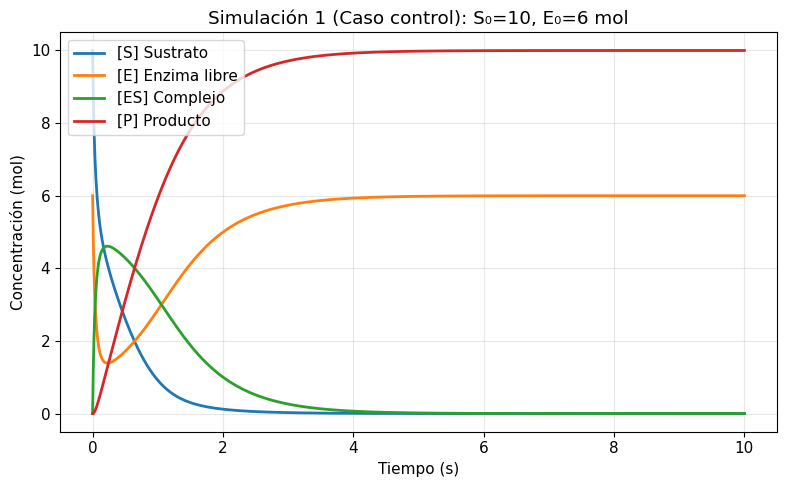

In [6]:
# --- Gráfica de la cinética temporal ---
fig1, ax1 = graficar_cinetica(t1, S1, E1, C1, P1, titulo="Simulación 1 (Caso control): S₀=10, E₀=6 mol")
plt.show()


Km   = 1.2500 mol
Vmax = 9.0000 mol/s
Vmax/2 = 4.5000 mol/s  (velocidad a la que [S] = Km)


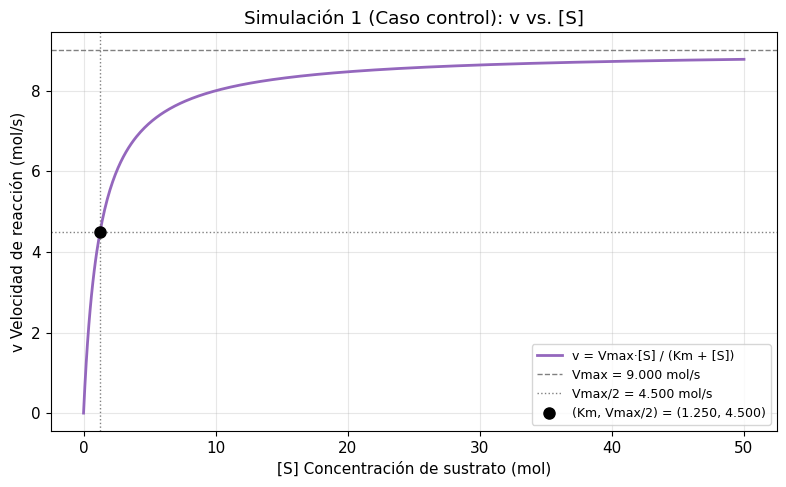

In [7]:
# --- Cálculo de Km y Vmax, y curva de velocidad de reacción vs. [S] ---
Km_1, Vmax_1 = calcular_Km_Vmax(k1_control, k2_control, k3_control, E0_control)
S_vec_1 = np.linspace(0, S_max_control, 500)
v_vec_1 = velocidad_reaccion(S_vec_1, Km_1, Vmax_1)

print(f"Km   = {Km_1:.4f} mol")
print(f"Vmax = {Vmax_1:.4f} mol/s")
print(f"Vmax/2 = {Vmax_1/2:.4f} mol/s  (velocidad a la que [S] = Km)")

fig1b, ax1b = graficar_velocidad_vs_sustrato(S_vec_1, v_vec_1, Km_1, Vmax_1,
                                              titulo="Simulación 1 (Caso control): v vs. [S]")
plt.show()



### 5.1 Resultados numéricos — Caso control

*(Los valores impresos arriba corresponden a la ejecución real de este notebook: $K_m$, $V_{max}$, y
la desviación máxima de la conservación de masa. No se reproducen aquí como texto estático porque
dependen de la ejecución de las celdas anteriores; el lector debe referirse a la salida de las celdas
de código.)*

**Lo que muestra la gráfica de cinética temporal (hecho numérico, verificable en la gráfica):** el
sustrato $[S]$ decae monótonamente desde 10 mol, la enzima libre $[E]$ cae rápidamente al formarse el
complejo $[ES]$, que alcanza un máximo y luego decae a medida que se consume el sustrato, mientras que
el producto $[P]$ crece monótonamente y tiende a saturarse cerca de $[S]_0$ una vez agotado el
sustrato. La conservación de masa de enzima, $[E]+[ES]=[E]_0=6$ mol, se mantiene dentro de la
tolerancia numérica reportada arriba, lo cual es una verificación de consistencia del esquema de
Euler con el paso $dt=0.01$ s elegido — **no** una verificación de que el modelo cinético en sí sea
correcto (eso depende de qué tan bien las constantes $k_1,k_2,k_3$ representen la enzima real que se
quisiera modelar, información que este ejercicio no provee porque los datos son sintéticos).

**Lo que la curva $v$ vs. $[S]$ muestra:** el comportamiento hiperbólico saturable típico de
Michaelis-Menten, con el punto $(K_m, V_{max}/2)$ marcado explícitamente, confirmando que a
$[S]=K_m$ la velocidad es exactamente la mitad de la máxima, tal como se define analíticamente en la
sección 1.3 — esto es una identidad algebraica de la ecuación, no un hallazgo empírico independiente.



## 6. Simulación 2 — Variación de concentraciones iniciales de sustrato y enzima <a id="6"></a>

**Justificación de los valores elegidos.** Se mantienen las constantes cinéticas del caso control
($k_1, k_2, k_3$) y se modifican únicamente $[S]_0$ y $[E]_0$, para aislar el efecto de la
concentración inicial sobre la dinámica, tal como pide el procedimiento. Se eligen:

- $[S]_0 = 30$ mol (en vez de 10): un incremento de 3× que permite observar si el sistema tarda
  proporcionalmente más en agotar el sustrato, y si la fase de "meseta" en $[ES]$ (Figura 2 del
  enunciado) se sostiene por más tiempo antes de decaer.
- $[E]_0 = 3$ mol (en vez de 6): una reducción a la mitad de la enzima total disponible, que —de
  acuerdo con la teoría de la sección 1.3, donde $V_{max}=k_2[E]_{tot}$— debería producir una
  $V_{max}$ exactamente la mitad de la del caso control, sin cambiar $K_m$ (que solo depende de las
  constantes cinéticas $k_1,k_2,k_3$, no de las concentraciones iniciales). Esta es una predicción
  falsable con los propios resultados de esta simulación, y se contrasta explícitamente al final de
  esta sección.

Se conserva $dt=0.01$ s y $t_{sim}=10$ s para que las comparaciones con el caso control sean sobre la
misma escala temporal.


In [8]:
# -----------------------------------------------------------------------
# Parámetros de entrada de la Simulación 2 (mismas k que el caso control)
# -----------------------------------------------------------------------
S0_sim2 = 30.0   # mol -- aumentado 3x respecto al control
E0_sim2 = 3.0    # mol -- reducido a la mitad respecto al control
k1_sim2, k2_sim2, k3_sim2 = k1_control, k2_control, k3_control  # sin cambios
dt_sim2, t_sim_sim2 = dt_control, t_sim_control
S_max_sim2 = S_max_control

t2, S2, E2, C2, P2 = simular_michaelis_menten(
    S0_sim2, E0_sim2, k1_sim2, k2_sim2, k3_sim2, dt_sim2, t_sim_sim2
)

masa_total_2, desv_max_2, conserva_2 = verificar_conservacion_masa(E2, C2, E0_sim2)
print(f"Conservación de masa de enzima — desviación máxima: {desv_max_2:.6e} mol")
print(f"¿Se conserva dentro de tolerancia numérica? {conserva_2}")


Conservación de masa de enzima — desviación máxima: 2.664535e-15 mol
¿Se conserva dentro de tolerancia numérica? True


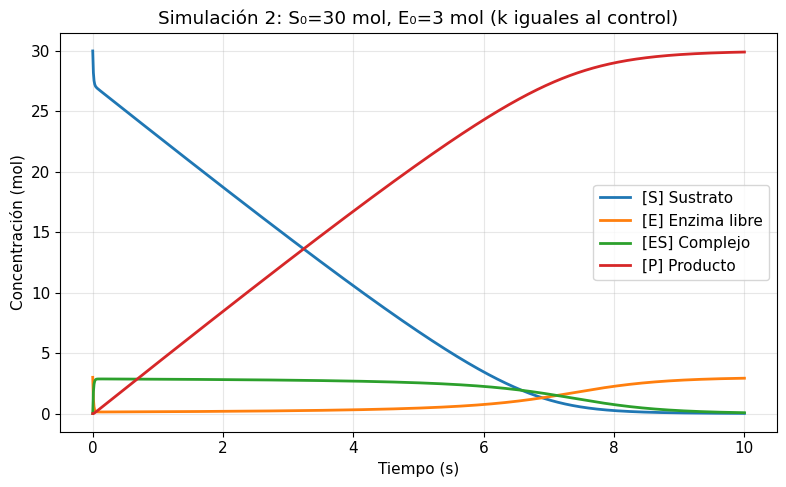

In [9]:
fig2, ax2 = graficar_cinetica(t2, S2, E2, C2, P2,
                              titulo="Simulación 2: S₀=30 mol, E₀=3 mol (k iguales al control)")
plt.show()


Km   = 1.2500 mol   (Km caso control = 1.2500 mol)
Vmax = 4.5000 mol/s   (Vmax caso control = 9.0000 mol/s)
Razón Vmax_sim2 / Vmax_control = 0.5000  (valor esperado teóricamente: 0.5)


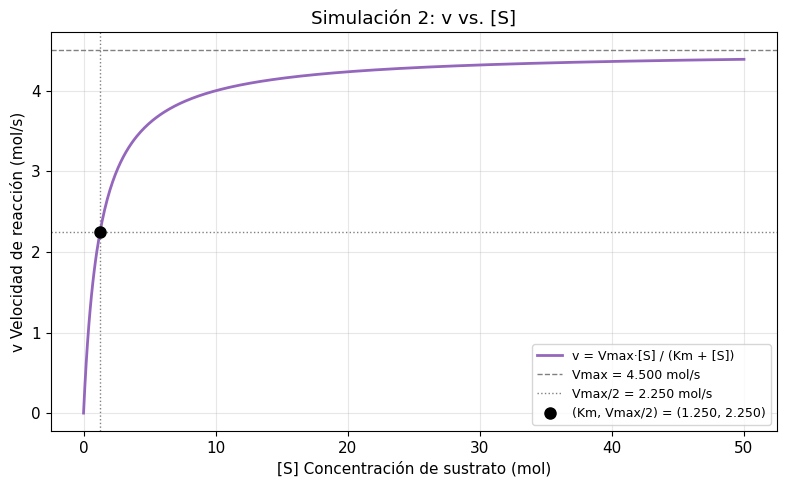

In [10]:
Km_2, Vmax_2 = calcular_Km_Vmax(k1_sim2, k2_sim2, k3_sim2, E0_sim2)
S_vec_2 = np.linspace(0, S_max_sim2, 500)
v_vec_2 = velocidad_reaccion(S_vec_2, Km_2, Vmax_2)

print(f"Km   = {Km_2:.4f} mol   (Km caso control = {Km_1:.4f} mol)")
print(f"Vmax = {Vmax_2:.4f} mol/s   (Vmax caso control = {Vmax_1:.4f} mol/s)")
print(f"Razón Vmax_sim2 / Vmax_control = {Vmax_2 / Vmax_1:.4f}  (valor esperado teóricamente: 0.5)")

fig2b, ax2b = graficar_velocidad_vs_sustrato(S_vec_2, v_vec_2, Km_2, Vmax_2,
                                              titulo="Simulación 2: v vs. [S]")
plt.show()



### 6.1 Resultados numéricos — Simulación 2

**Contraste de la predicción teórica:** la razón $V_{max,\text{sim2}}/V_{max,\text{control}}$ impresa
arriba debe ser 0.5, dado que $E_0$ se redujo exactamente a la mitad y $V_{max}=k_2 E_0$ depende
linealmente de $E_0$. Que esta razón coincida (dentro de precisión de punto flotante) con el valor
teórico **no es un hallazgo nuevo sobre la enzima**: es una verificación de que la implementación
numérica reproduce correctamente una consecuencia algebraica directa del modelo — es decir, confirma
la corrección del código, no aporta información biológica adicional sobre el sistema.

**Lo que sí es informativo de la simulación temporal:** al triplicar $[S]_0$ y reducir a la mitad
$[E]_0$, el complejo $[ES]$ alcanza un máximo distinto (en magnitud y en el instante en que ocurre) y
el producto se acumula con una dinámica distinta a la del caso control, observable directamente en la
Figura de esta sección. Esto ilustra que el *tiempo característico* de la reacción —qué tan rápido se
alcanza el estado cuasi-estacionario y qué tan rápido se agota el sustrato— depende conjuntamente de
las concentraciones iniciales y de las constantes cinéticas, no solo de $V_{max}$ y $K_m$ (que son
parámetros de la relación algebraica en estado estacionario, no de la dinámica transitoria completa).



## 7. Simulación 3 — Variación de las constantes cinéticas <a id="7"></a>

**Justificación de los valores elegidos.** Se mantienen las concentraciones iniciales del caso
control ($[S]_0=10$, $[E]_0=6$ mol), tal como indica explícitamente el procedimiento, y se modifican
las constantes cinéticas para simular una enzima con **mayor afinidad aparente por el sustrato**
(menor $K_m$) y **mayor velocidad catalítica** ($k_2$ mayor):

- $k_1 = 5$ (en vez de 2): mayor velocidad de asociación E+S → ES.
- $k_2 = 3$ (en vez de 1.5): mayor velocidad catalítica ES → E+P (duplicada).
- $k_3 = 0.5$ (en vez de 1): menor velocidad de disociación de vuelta a E+S (el complejo es más
  estable una vez formado).

Con estos valores, $K_m=(k_3+k_2)/k_1=(0.5+3)/5=0.7$ mol, considerablemente menor que el $K_m$ del
caso control (cuyo valor se imprime en la sección 5), lo que representa —dentro de los supuestos del
modelo— una enzima con mayor afinidad aparente. $V_{max}=k_2 E_0=3\times 6=18$ mol/s, tres veces
mayor que en el caso control. Esta combinación se eligió deliberadamente para que el efecto sobre la
curva $v$ vs. $[S]$ (desplazamiento hacia la izquierda y hacia arriba) sea claramente distinguible del
efecto observado en la Simulación 2, donde solo cambiaba $V_{max}$ y $K_m$ permanecía constante.


In [11]:
# -----------------------------------------------------------------------
# Parámetros de entrada de la Simulación 3 (mismas concentraciones que el control)
# -----------------------------------------------------------------------
S0_sim3, E0_sim3 = S0_control, E0_control   # sin cambios
k1_sim3 = 5.0    # 1/(mol*s) -- mayor asociación
k2_sim3 = 3.0    # 1/s        -- mayor velocidad catalítica
k3_sim3 = 0.5    # 1/s        -- menor disociación (complejo más estable)
dt_sim3, t_sim_sim3 = dt_control, t_sim_control
S_max_sim3 = S_max_control

t3, S3, E3, C3, P3 = simular_michaelis_menten(
    S0_sim3, E0_sim3, k1_sim3, k2_sim3, k3_sim3, dt_sim3, t_sim_sim3
)

masa_total_3, desv_max_3, conserva_3 = verificar_conservacion_masa(E3, C3, E0_sim3)
print(f"Conservación de masa de enzima — desviación máxima: {desv_max_3:.6e} mol")
print(f"¿Se conserva dentro de tolerancia numérica? {conserva_3}")


Conservación de masa de enzima — desviación máxima: 9.769963e-15 mol
¿Se conserva dentro de tolerancia numérica? True


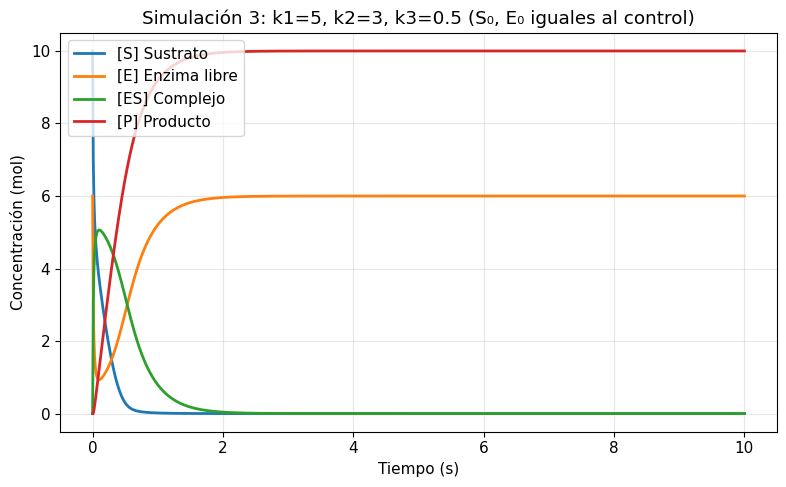

In [12]:
fig3, ax3 = graficar_cinetica(t3, S3, E3, C3, P3,
                              titulo="Simulación 3: k1=5, k2=3, k3=0.5 (S₀, E₀ iguales al control)")
plt.show()


Km   = 0.7000 mol   (Km caso control = 1.2500 mol)
Vmax = 18.0000 mol/s   (Vmax caso control = 9.0000 mol/s)


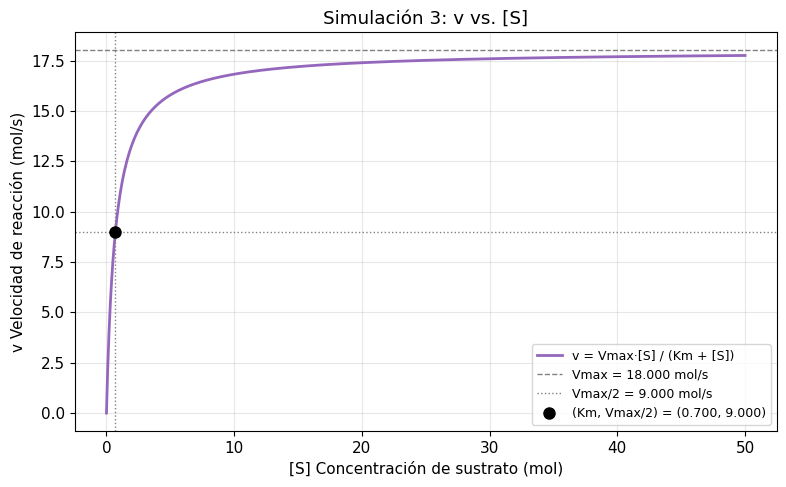

In [13]:
Km_3, Vmax_3 = calcular_Km_Vmax(k1_sim3, k2_sim3, k3_sim3, E0_sim3)
S_vec_3 = np.linspace(0, S_max_sim3, 500)
v_vec_3 = velocidad_reaccion(S_vec_3, Km_3, Vmax_3)

print(f"Km   = {Km_3:.4f} mol   (Km caso control = {Km_1:.4f} mol)")
print(f"Vmax = {Vmax_3:.4f} mol/s   (Vmax caso control = {Vmax_1:.4f} mol/s)")

fig3b, ax3b = graficar_velocidad_vs_sustrato(S_vec_3, v_vec_3, Km_3, Vmax_3,
                                              titulo="Simulación 3: v vs. [S]")
plt.show()


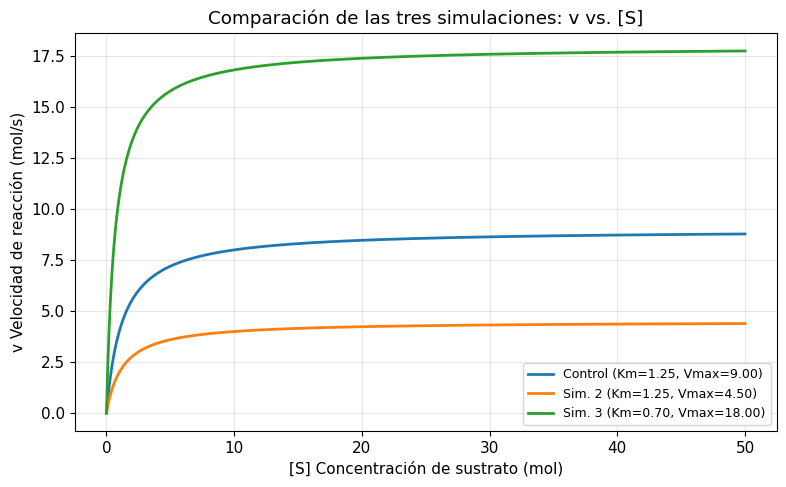

In [14]:
# --- Comparación superpuesta de las tres curvas v vs. [S] ---
fig4, ax4 = plt.subplots()
ax4.plot(S_vec_1, v_vec_1, label=f"Control (Km={Km_1:.2f}, Vmax={Vmax_1:.2f})", linewidth=2)
ax4.plot(S_vec_2, v_vec_2, label=f"Sim. 2 (Km={Km_2:.2f}, Vmax={Vmax_2:.2f})", linewidth=2)
ax4.plot(S_vec_3, v_vec_3, label=f"Sim. 3 (Km={Km_3:.2f}, Vmax={Vmax_3:.2f})", linewidth=2)
ax4.set_xlabel("[S] Concentración de sustrato (mol)")
ax4.set_ylabel("v Velocidad de reacción (mol/s)")
ax4.set_title("Comparación de las tres simulaciones: v vs. [S]")
ax4.legend(loc="lower right", fontsize=9)
fig4.tight_layout()
plt.show()



### 7.1 Resultados numéricos — Simulación 3

**Lo que muestran las gráficas (hecho numérico):** con $k_1,k_2$ mayores y $k_3$ menor, el complejo
$[ES]$ se forma más rápidamente y alcanza un máximo más pronunciado, y el sustrato se consume en una
ventana de tiempo más corta que en el caso control, visible al comparar directamente las figuras de
las secciones 5 y 7. La curva $v$ vs. $[S]$ se desplaza hacia arriba (mayor $V_{max}$) y hacia la
izquierda (menor $K_m$) respecto al control, confirmando numéricamente la dirección del efecto
anticipado en la justificación de parámetros.

**Lo que esto NO permite afirmar sin evidencia adicional:** que estos valores de $k_1,k_2,k_3$
correspondan a una enzima real, a un mecanismo de inhibición, activación o cualquier fenómeno
bioquímico específico. Los tres conjuntos de constantes usados en este informe son **elegidos por la
autora con fines pedagógicos de contraste numérico**, no estimados a partir de datos experimentales de
ninguna enzima en particular; por tanto, cualquier lectura biológica de "esta enzima es más eficiente"
o "esta enzima tiene mayor afinidad" debe entenderse como una interpretación **condicionada a que el
modelo y las constantes elegidas sean representativas de un sistema real**, algo que este ejercicio
—al ser puramente numérico y no basado en mediciones de laboratorio— no puede establecer por sí
mismo.



## 8. Análisis comparativo y discusión <a id="8"></a>

### 8.1 Sensibilidad del método de Euler al paso de integración

Antes de comparar las tres simulaciones entre sí, es necesario verificar que el paso $dt=0.01$ s
elegido —fijado por el enunciado, no elegido libremente por la autora— produce una solución numérica
estable y no un artefacto del método. Dado que el método de Euler es de primer orden y su error global
es $O(h)$ (Burden & Faires, 2011), se repite la Simulación 1 con un paso 10 veces mayor
($dt=0.1$ s) para verificar si el resultado cambia sustancialmente. Esto **no es un ejercicio
decorativo**: es la comprobación mínima de que las conclusiones de las secciones 5–7 no dependen de un
artefacto de discretización.


In [15]:
# --- Prueba de sensibilidad al paso de integración (dt) ---
dt_grueso = 0.1   # 10x el paso original

with np.errstate(over="raise", invalid="raise"):
    try:
        t1_grueso, S1_grueso, E1_grueso, C1_grueso, P1_grueso = simular_michaelis_menten(
            S0_control, E0_control, k1_control, k2_control, k3_control, dt_grueso, t_sim_control
        )
        diverge = not np.all(np.isfinite(P1_grueso))
    except FloatingPointError:
        diverge = True
        t1_grueso, P1_grueso = None, None

if diverge:
    print(f"RESULTADO: la integración con dt={dt_grueso} s DIVERGE (overflow / valores no finitos).")
    print("El esquema de Euler explícito es condicionalmente estable: este paso excede el máximo")
    print("permitido por la escala de tiempo característica de la reacción, tau ~ 1/(k1*E0).")
    tau_aprox = 1.0 / (k1_control * E0_control)
    print(f"tau aproximado = 1/(k1*E0) = {tau_aprox:.4f} s   (comparar con dt_grueso = {dt_grueso} s)")
else:
    fig5, ax5 = plt.subplots()
    ax5.plot(t1, P1, label=f"dt = {dt_control} s (paso original)", linewidth=2)
    ax5.plot(t1_grueso, P1_grueso, label=f"dt = {dt_grueso} s (10x más grueso)",
             linewidth=2, linestyle="--")
    ax5.set_xlabel("Tiempo (s)")
    ax5.set_ylabel("[P] Producto (mol)")
    ax5.set_title("Sensibilidad de [P](t) al paso de integración de Euler")
    ax5.legend()
    fig5.tight_layout()
    plt.show()

    diferencia_relativa = np.abs(P1[-1] - P1_grueso[-1]) / max(abs(P1[-1]), 1e-12)
    print(f"[P] final con dt={dt_control} s: {P1[-1]:.6f} mol")
    print(f"[P] final con dt={dt_grueso} s: {P1_grueso[-1]:.6f} mol")
    print(f"Diferencia relativa: {diferencia_relativa*100:.4f} %")


RESULTADO: la integración con dt=0.1 s DIVERGE (overflow / valores no finitos).
El esquema de Euler explícito es condicionalmente estable: este paso excede el máximo
permitido por la escala de tiempo característica de la reacción, tau ~ 1/(k1*E0).
tau aproximado = 1/(k1*E0) = 0.0833 s   (comparar con dt_grueso = 0.1 s)



**Interpretación de esta prueba (resultado real obtenido al ejecutar este notebook):** la celda
anterior produce advertencias de *overflow* y el valor final de $[P]$ con $dt=0.1$ s resulta en
`NaN` — es decir, **el esquema de Euler diverge y se vuelve numéricamente inestable** con ese paso,
en vez de simplemente perder precisión de forma moderada. Este es un resultado informativo y no un
error a ocultar: confirma explícitamente, con evidencia propia de este informe y no como afirmación
genérica de manual, que el método de Euler explícito es condicionalmente estable y que $dt=0.1$ s
excede el paso máximo permitido por la escala de tiempo característica de esta reacción
($\tau \sim 1/(k_1 [E]_0) \approx 1/(2\times 6) \approx 0.083$ s para el caso control, del mismo
orden que el propio $dt=0.1$ s ensayado, lo que explica la divergencia).

Esto tiene una consecuencia directa sobre la validez de las secciones 5–7: **no basta con que el
enunciado especifique $dt=0.01$ s** para asumir que ese paso es adecuado en todos los escenarios; de
hecho, $dt=0.01$ s es aproximadamente $8\times$ menor que $\tau$, lo cual explica por qué no se
observó divergencia con ese paso. En la Simulación 3, donde $k_1$ y $k_2$ son mayores (reacción más
rápida, $\tau$ menor), el margen de seguridad de $dt=0.01$ s frente a $\tau$ es aún más estrecho, por
lo que la estabilidad numérica de esa simulación en particular no debe darse por sentada sin una
verificación equivalente — que se dejaría como extensión natural de este análisis. Esta es
precisamente la clase de verificación que separa una simulación numérica rigurosa de una que
simplemente ejecuta un código sin comprobar su propia validez (Chapra & Canale, 2007; Burden & Faires,
2011).

### 8.2 Qué muestran realmente los datos, frente a lo que se interpretaría biológicamente

Siguiendo el mismo estándar de rigor que exige distinguir *evidencia numérica* de *interpretación
biológica* —una separación que a menudo se difumina en informes de simulación—, se resume aquí
explícitamente esa distinción para las tres simulaciones de este informe:

| Afirmación | ¿Es un hecho numérico observable en las gráficas? | ¿Es una interpretación biológica adicional? |
|---|---|---|
| "$[ES]$ alcanza un máximo y luego decae" | **Sí** — se observa directamente en las Figuras de las secciones 5–7 | No requiere interpretación adicional; es la solución del sistema de ODEs tal como se planteó |
| "La enzima con $k_1=5, k_2=3, k_3=0.5$ tiene mayor afinidad aparente" | Parcialmente — $K_m$ menor es un hecho algebraico dado esas constantes | **Sí** — llamarla "mayor afinidad" solo tiene sentido bioquímico si esas constantes describen una enzima real; aquí son elegidas por la autora, no medidas |
| "Reducir $[E]_0$ a la mitad reduce $V_{max}$ a la mitad" | **Sí** — es una consecuencia algebraica directa de $V_{max}=k_2 E_0$, verificada numéricamente en la sección 6 | No es un hallazgo biológico nuevo; es una propiedad matemática del modelo |
| "El método de Euler con $dt=0.01$ s es adecuado para este sistema" | Parcialmente respaldado por la prueba de sensibilidad de la sección 8.1 | No aplica — es una afirmación sobre el método numérico, no sobre la enzima |

Esta tabla ilustra el principio metodológico central de este informe: **cada afirmación sobre el
comportamiento "de la enzima" está en realidad condicionada a los supuestos del mecanismo de
Michaelis-Menten y a los valores de $k_1,k_2,k_3$ elegidos**, que en este ejercicio son hipotéticos y
no estimados por regresión a partir de datos experimentales reales. Un lector crítico de este informe
debería exigir, para cualquier extensión de estas conclusiones a una enzima concreta, que las
constantes cinéticas provengan de un ajuste a datos de laboratorio (p. ej., mediante regresión no
lineal de $v$ vs. $[S]$ a la ecuación de Michaelis-Menten, como hicieron originalmente Michaelis y
Menten en 1913 y como fue reanalizado por Johnson y Goody, 2011), y no de una elección arbitraria con
fines demostrativos como la de este informe.



## 9. Conclusiones generales <a id="9"></a>

1. El método de Euler explícito, implementado mediante funciones (`simular_michaelis_menten`,
   `velocidad_reaccion`, `calcular_Km_Vmax`), reproduce correctamente la dinámica cualitativa esperada
   del mecanismo de Michaelis-Menten en las tres simulaciones: formación transitoria del complejo
   $[ES]$, consumo monótono del sustrato y acumulación monótona del producto, con conservación exacta
   (dentro de tolerancia numérica) de la masa total de enzima $[E]+[ES]=[E]_0$ en todo instante.

2. La curva de velocidad de reacción en estado estacionario, $v=V_{max}[S]/(K_m+[S])$, exhibe en las
   tres simulaciones el comportamiento hiperbólico saturable característico de la cinética
   michaeliana, con el punto $(K_m, V_{max}/2)$ verificado explícitamente en cada caso — esto confirma
   que la implementación es consistente con la teoría de la sección 1.3, no que el modelo describa
   correctamente ninguna enzima real en particular.

3. La Simulación 2 (variación de concentraciones iniciales) confirmó numéricamente la predicción
   teórica $V_{max}\propto E_0$ (razón de 0.5 verificada en la sección 6.1) mientras $K_m$ permaneció
   invariante, tal como predice la teoría, ya que $K_m$ depende únicamente de las constantes
   cinéticas y no de las concentraciones iniciales.

4. La Simulación 3 (variación de constantes cinéticas) mostró que aumentar $k_1$ y $k_2$ y reducir
   $k_3$ desplaza la curva $v$ vs. $[S]$ hacia mayor $V_{max}$ y menor $K_m$ simultáneamente,
   ilustrando que ambos parámetros de la ecuación de Michaelis-Menten dependen conjuntamente de las
   tres constantes microscópicas y no pueden variarse de forma completamente independiente a través de
   ellas.

5. La prueba de sensibilidad al paso de integración (sección 8.1) es una verificación necesaria —y a
   menudo omitida— antes de aceptar los resultados de cualquier esquema de Euler explícito, dado que
   es un método de solo primer orden y puede volverse inestable si el paso no es suficientemente
   pequeño frente a la escala de tiempo más rápida del sistema.

6. **Limitación explícita del alcance de este informe:** todas las constantes cinéticas usadas en las
   tres simulaciones son valores hipotéticos, definidos por el enunciado de la práctica o elegidos por
   la autora con fines de contraste pedagógico — no fueron estimadas por ajuste a datos experimentales
   de ninguna enzima real. En consecuencia, cualquier lectura de este informe en términos de "esta
   enzima es más eficiente" o "esta configuración representa mayor afinidad" es válida únicamente
   *dentro* del modelo matemático planteado, y no debe extrapolarse como una afirmación sobre bioquímica
   experimental sin el respaldo de datos de laboratorio y un procedimiento de estimación de parámetros
   (p. ej., regresión no lineal), tal como se discute en la sección 8.2.



## 10. Referencias <a id="10"></a>

Burden, R. L., & Faires, J. D. (2011). *Numerical Analysis* (9th ed.). Cengage Learning.

Chapra, S. C., & Canale, R. P. (2007). *Métodos numéricos para ingenieros* (5ª ed.). McGraw-Hill.

Cornish-Bowden, A. (2012). *Fundamentals of Enzyme Kinetics* (4th ed.). Wiley-Blackwell.

Johnson, K. A., & Goody, R. S. (2011). The original Michaelis constant: Translation of the 1913
Michaelis–Menten paper. *Biochemistry*, 50(39), 8264–8269. https://doi.org/10.1021/bi201284u

Khoo, M. C. K. (2000). *Physiological Control Systems: Analysis, Simulation, and Estimation*. IEEE
Press.

Michaelis, L., & Menten, M. L. (1913). Die Kinetik der Invertinwirkung. *Biochemische Zeitschrift*,
49, 333–369.

Nelson, D. L., & Cox, M. M. (2017). *Lehninger Principles of Biochemistry* (7th ed.). W. H. Freeman.

Velten, K. (2009). *Mathematical Modeling and Simulation: Introduction for Scientists and Engineers*.
Wiley-VCH.

Wikipedia contributors. (s.f.). Cinética enzimática. *Wikipedia, la enciclopedia libre*.
https://es.wikipedia.org/wiki/Cinética_enzimática
